In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
from preprocess import *
from utils import *
import numpy as np
import matplotlib.pyplot as plt
import harmonypy as hm

from train import Train

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [3]:
# savepath = 'Result'
# if not os.path.exists(savepath):
#     os.mkdir(savepath)

In [4]:
datasets_df = pd.DataFrame([['E9.5_E1S1.MOSTA', 'E9.5_E2S1.MOSTA', 'E9.5_E2S2.MOSTA', 'E9.5_E2S3.MOSTA', 'E9.5_E2S4.MOSTA']])
datasets_df.index = ['Sample1']
datasets_df.columns = ['Location1', 'Location2', 'Location3', 'Location4', 'Location5']
batch_tag = 'Sample1'
datasets = datasets_df.loc[batch_tag].values    # Sample
# datasets = datasets_df[batch_tag].values        # Location
dataset_tags = datasets

n_neighbor = 5
n_cluster = 13 if batch_tag != 'Sample2' else 5

epochs = 500
coord_type = 'spatial'
weights = [[60, 0.01, 0.01]]

adata_list = []

for i in range(len(datasets)):
    dataset = datasets[i]
    # print(dataset)
    file_fold = '../../../data/Mouse_Embryo/'
    adata = sc.read_h5ad(os.path.join(file_fold, dataset + '.h5ad'))
    adata.var_names_make_unique()

    # add ground_truth
    # df_meta = pd.read_csv(file_fold + '/manual_annotations.txt', sep='\t', header=None, index_col=0)
    # df_meta.columns = ['layer_guess']
    # adata.obs['ground_truth'] = df_meta['layer_guess'].values
    # # filter out NA nodes
    # adata = adata[~pd.isnull(adata.obs['ground_truth'])]

    adata.obs_names = [x + '_' + dataset for x in adata.obs_names]
    adata.obs['batch_name'] = [dataset] * adata.X.shape[0]
    adata_list.append(adata)
    
batch_adata = integrate_adata(adata_list, coord_type=coord_type, n_neighbor=n_neighbor)

Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2
Recommended l is 2


D:\anaconda\envs\njy\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:72: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


AnnData object with n_obs × n_vars = 26417 × 21440
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - Alx4', 'Regulon - Arx', 'Regulon - Atf1', 'Regulon - Bach1', 'Regulon - Barhl1', 'Regulon - Bcl3', 'Regulon - Bclaf1', 'Regulon - Bmyc', 'Regulon - Brf1', 'Regulon - Brf2', 'Regulon - Cdx1', 'Regulon - Cebpa', 'Regulon - Creb1', 'Regulon - Creb3l1', 'Regulon - Crx', 'Regulon - Ctcf', 'Regulon - Cux1', 'Regulon - Dbx1', 'Regulon - E2f1', 'Regulon - E2f2', 'Regulon - E2f3', 'Regulon - E2f4', 'Regulon - E2f5', 'Regulon - E2f6', 'Regulon - Egr4', 'Regulon - Elf2', 'Regulon - Elk1', 'Regulon - Elk3', 'Regulon - En1', 'Regulon - Ep300', 'Regulon - Erg', 'Regulon - Esrra', 'Regulon - Ets2', 'Regulon - Etv2', 'Regulon - Etv4', 'Regulon - Etv5', 'Regulon - Evx1', 'Regulon - Ezh2', 'Regulon - Figla', 'Regulon - Fli1', 'Regulon - Foxa1', 'Regulon - Foxa2', 'Regulon - Foxa3', 'Regulon - Foxd1', 'Regulon - Foxf1', 'Regulon - Foxj3

In [5]:
for mse_weight, graph_weight, nce_weight in weights:
    set = batch_tag + "_" + str(n_neighbor) + "_" + str(mse_weight) + "_" + str(graph_weight) \
        + "_" + str(nce_weight) + "_" + str(epochs)
    print(set)
    print("*" * 70)
    
    model = Train(batch_adata, device=device, epochs=epochs, mse_weight=mse_weight,
                      graph_weight=graph_weight, nce_weight=nce_weight, coord_type=coord_type,
                      n_neighbor=n_neighbor, n_cluster=n_cluster, protocol='10X')
    batch_adata = model.train()

    # Harmony
    data_mat = batch_adata.obsm['emb'].copy()
    vars_use = ['batch_name']
    meta_data = batch_adata.obs[vars_use]
    # Run Harmony
    ho = hm.run_harmony(data_mat, meta_data, vars_use)
    batch_adata.obsm['Harmony_Revised'] = ho.Z_corr.T

    method = 'mclust'  # mclust, leiden, louvain, kmeans
    cluster(batch_adata, n_clusters=n_cluster, method=method, key='Harmony_Revised')

    domain_tag = 'domain'
    embed_tag = 'Harmony_Revised'

    # filter out NA nodes
    # sub_adata = batch_adata[~pd.isnull(batch_adata.obs['ground_truth'])]

    # sc.set_figure_params(vector_friendly=True, figsize=(4.5 / 2.54, 4.5 / 2.54))
    # fig, ax_list = plt.subplots(1, 4, figsize=(5 / 2.54 * 4, 5 / 2.54))
    # ### Plotting UMAP before batch effect correction
    # sc.pp.pca(sub_adata)
    # sc.pp.neighbors(sub_adata, use_rep='X_pca')
    # sc.tl.umap(sub_adata)
    # sc.pl.umap(sub_adata, color='batch_name', title='Uncorrected', ax=ax_list[0], frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # ### Plotting UMAP after batch effect correction
    # sc.pp.neighbors(sub_adata, use_rep=embed_tag)
    # sc.tl.umap(sub_adata)
    # sc.pl.umap(sub_adata, color='batch_name', ax=ax_list[1], title='Batch corrected', frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # 
    # sc.pl.umap(sub_adata, color='ground_truth', ax=ax_list[2], title='Ground Truth', frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # sc.pl.umap(sub_adata, color=domain_tag, ax=ax_list[3], title='Predict Domain', frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # plt.savefig(savepath + f'SpaGIC_{batch_tag}_umap_hm.png', bbox_inches='tight', dpi=300)
    # # plt.savefig(savepath + f'SpaGIC_{batch_tag}_umap_hm.pdf', bbox_inches='tight', dpi=300)
    # # plt.show()
    # plt.close()

    # scores
    # ARI = adjusted_rand_score(sub_adata.obs['ground_truth'], sub_adata.obs[domain_tag])
    # NMI = normalized_mutual_info_score(sub_adata.obs['ground_truth'], sub_adata.obs[domain_tag])
    # print(f'{batch_tag}, ARI: {ARI}; NMI: {NMI}')

    #### single slice visual
    # sc.set_figure_params(vector_friendly=True, figsize=(3.2 / 2.54, 3.5 / 2.54))
    # fig, axs = plt.subplots(1, len(datasets), figsize=(4.5 * len(datasets), 3))
    # for idx, single_adata in enumerate(adata_list):
    #     single_adata.obs[domain_tag] = batch_adata[batch_adata.obs['batch_name'] == datasets[idx]].obs[domain_tag].values
    #     # filter out NA nodes
    #     sub_adata = single_adata[~pd.isnull(single_adata.obs['ground_truth'])]
    #     refine(sub_adata, radius=50, key=domain_tag)
    #     key = 'domain_refined'
    #     ARI = adjusted_rand_score(sub_adata.obs['ground_truth'], sub_adata.obs[key])
    #     NMI = normalized_mutual_info_score(sub_adata.obs['ground_truth'], sub_adata.obs[key])
    #     print(f'{datasets[idx]}, ARI: {ARI}; NMI: {NMI}')
    #     sc.pl.spatial(sub_adata, img_key="hires", ax=axs[idx], color=key, frameon=False, legend_fontsize=8,
    #                   title=f'{datasets[idx]}_ARI=%.4f-NMI=%.4f' % (ARI, NMI), show=False)
    # plt.savefig(savepath + f'SpaGIC_{batch_tag}_sp_hm.png', bbox_inches='tight', dpi=300)
    # plt.savefig(savepath + f'SpaGIC_{batch_tag}_sp_hm.pdf', bbox_inches='tight', dpi=300)
    # plt.show()
    # plt.close()

Sample1_5_60_0.01_0.01_500
**********************************************************************
Begin to train...


100%|██████████| 500/500 [1:29:47<00:00, 10.78s/it]


Optimization finished!


2024-12-30 20:33:51,662 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-12-30 20:33:55,604 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-12-30 20:33:55,757 - harmonypy - INFO - Iteration 1 of 10
2024-12-30 20:34:03,940 - harmonypy - INFO - Iteration 2 of 10
2024-12-30 20:34:12,106 - harmonypy - INFO - Iteration 3 of 10
2024-12-30 20:34:20,373 - harmonypy - INFO - Iteration 4 of 10
2024-12-30 20:34:28,792 - harmonypy - INFO - Iteration 5 of 10
2024-12-30 20:34:36,834 - harmonypy - INFO - Converged after 5 iterations


clustering...


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [6]:
batch_adata.write('SpaGIC_MOE.h5ad')

In [ ]:
batch_adata

In [7]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [9]:
sub_adata = batch_adata[~pd.isnull(batch_adata.obs['annotation'])]
ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['domain'])
print(f"total ARI:{ARI}")
for name in datasets:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    ARI = ari_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['domain'])
    print(f"{name} ARI:{ARI}")

total ARI:0.24663713122956973
E9.5_E1S1.MOSTA ARI:0.2419888150192738
E9.5_E2S1.MOSTA ARI:0.3297047555572372
E9.5_E2S2.MOSTA ARI:0.3450830221935887
E9.5_E2S3.MOSTA ARI:0.3654751297655098
E9.5_E2S4.MOSTA ARI:0.2960245661145575


In [10]:
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['domain'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata.obs['annotation'], sub_adata.obs['domain'])
print(f"total AMI:{AMI}")
for name in datasets:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['domain'])
    AMI = ami_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['domain'])
    ACC = 1/2 * (NMI + AMI)
    print(f"{name} ACC:{ACC}")

total NMI:0.44941975191401035
total AMI:0.44855771935106453
E9.5_E1S1.MOSTA ACC:0.49089720712540796
E9.5_E2S1.MOSTA ACC:0.5385175128515316
E9.5_E2S2.MOSTA ACC:0.5467549921378996
E9.5_E2S3.MOSTA ACC:0.5915730894677103
E9.5_E2S4.MOSTA ACC:0.5166247169013933


In [11]:
sub_adata = batch_adata[~pd.isnull(batch_adata.obs['annotation'])]
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['domain'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata.obs['annotation'], sub_adata.obs['domain'])
print(f"total COM:{COM}")
for name in datasets:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    HOM = hom_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['domain'])
    COM = com_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['domain'])
    V =  2 * ((HOM * COM) / (HOM + COM))
    print(f"{name} V:{V}")

total HOM:0.4294884899495038
total COM:0.47129093912633757
E9.5_E1S1.MOSTA V:0.49216497384536045
E9.5_E2S1.MOSTA V:0.5399687088686862
E9.5_E2S2.MOSTA V:0.5483299090928223
E9.5_E2S3.MOSTA V:0.5928237466845422
E9.5_E2S4.MOSTA V:0.5179631121448276


1.8919678339539963
1.5617654363129643


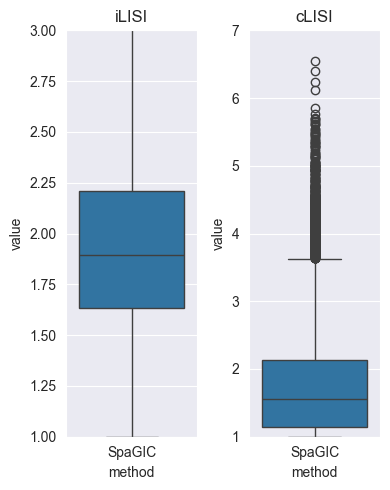

In [12]:
import harmonypy as hm

iLISI = hm.compute_lisi(batch_adata.obsm['Harmony_Revised'], batch_adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
cLISI = hm.compute_lisi(batch_adata.obsm['Harmony_Revised'], batch_adata.obs[['annotation']], label_colnames=['annotation'])[:, 0]

df_iLISI = pd.DataFrame({
    'method': 'SpaGIC',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

df_cLISI = pd.DataFrame({
    'method': 'SpaGIC',
    'value': cLISI,
    'type': ['CLISI'] * len(cLISI)
})

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
print(np.median(cLISI))

D:\anaconda\envs\njy\Lib\site-packages\scanpy\plotting\_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
D:\anaconda\envs\njy\Lib\site-packages\scanpy\plotting\_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
D:\anaconda\envs\njy\Lib\site-packages\scanpy\plotting\_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
D:\anaconda\envs\njy\Lib\site-packages\scanpy\plotting\_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
D:\anaconda\envs\njy\Lib\site-packages\scanpy\plotting\_utils.py:465: ImplicitModificationWarning: T

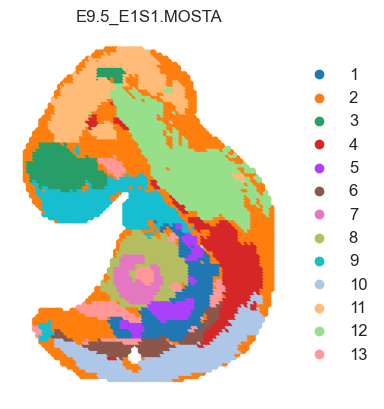

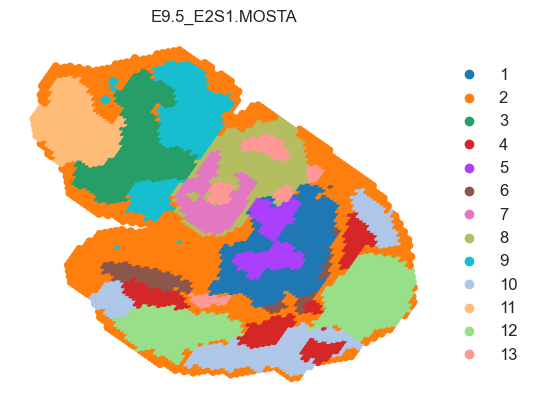

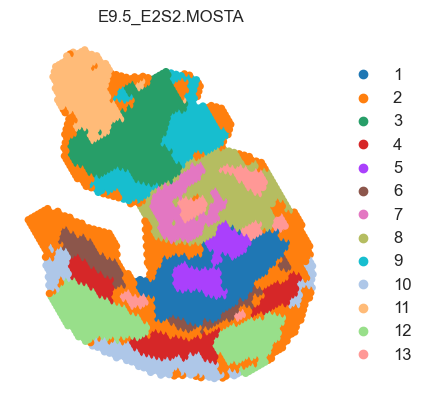

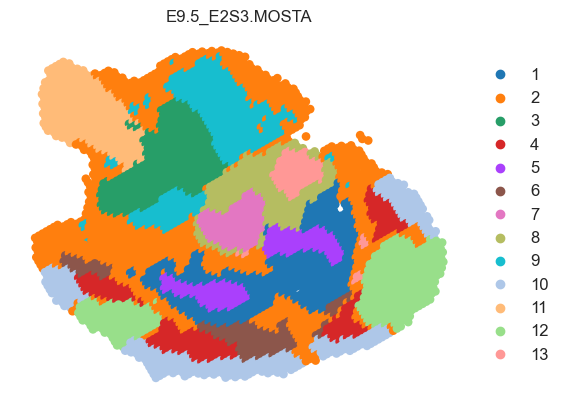

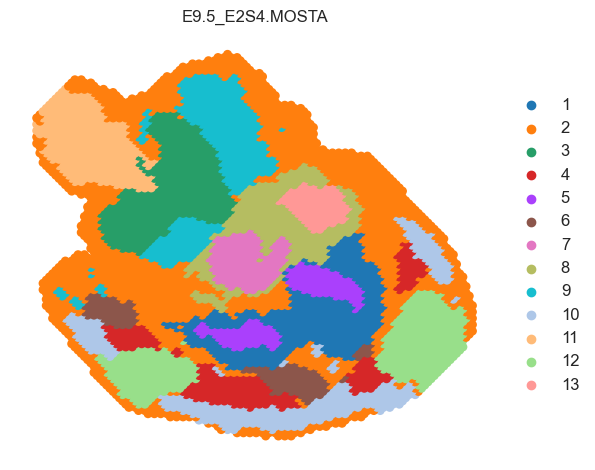

In [15]:
import matplotlib.pyplot as plt

spot_size = 2
for slice_id, slice_name in enumerate(datasets):
    adata_tmp = batch_adata[batch_adata.obs['batch_name'] == datasets[slice_id]]
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=12, show=False, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
plt.tight_layout()